# 🔫 ANVIKSHA : AI Based Infiltration Risk Prediction and Decision Support System — Weapon Detection Training

This notebook trains a **YOLOv8** model on the `weapon_detection` dataset from **scratch**.

| Setting | Value |
|---|---|
| Model | YOLOv8n (nano) |
| Dataset | weapon_detection/ |
| Classes | 9 (Rifle, Bazooka, Grenade Launcher, Handgun, Knife, SMG, Shotgun, Sniper, Sword) |
| Epochs | 50 |
| Image Size | 640 |
| Batch Size | 8 |

> **Output:** `runs/detect/runs/detect/weapons/weights/best.pt` — use this in your surveillance system.

## 📦 Cell 1 — Install Dependencies

In [14]:
# Install ultralytics if not already installed
import subprocess, sys

try:
    import ultralytics
    print(f"✅ Ultralytics already installed (v{ultralytics.__version__})")
except ImportError:
    print("📥 Installing ultralytics...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "ultralytics"])
    print("✅ Ultralytics installed!")

✅ Ultralytics already installed (v8.4.16)


## ⚙️ Cell 2 — Configuration

In [ ]:
import os
from pathlib import Path

# ── CONFIG ────────────────────────────────────────────────────
DATASET_YAML = "weapon_detection/dataset.yaml"
BASE_MODEL   = "yolov8n.pt"    # nano model; swap for yolov8s.pt / yolov8m.pt for higher accuracy
EPOCHS       = 50
IMG_SIZE     = 640
BATCH_SIZE   = 8
PROJECT_NAME = "runs/detect"   # YOLO internally saves under runs/detect/runs/detect/<name>
RUN_NAME     = "weapons"
DEVICE       = "cpu"           # ← change to 0 if you have an NVIDIA GPU
WORKERS      = 2
PATIENCE     = 10              # early stopping patience

# ── ACTUAL SAVE PATH (YOLO doubles the project path) ──────────
# YOLOv8 saves to: runs/detect/runs/detect/<RUN_NAME>/
ACTUAL_RUN_DIR   = Path(PROJECT_NAME) / PROJECT_NAME / RUN_NAME
BEST_WEIGHTS     = ACTUAL_RUN_DIR / "weights" / "best.pt"
LAST_WEIGHTS     = ACTUAL_RUN_DIR / "weights" / "last.pt"

print("Configuration loaded ✅")
print(f"  Dataset      : {DATASET_YAML}")
print(f"  Model        : {BASE_MODEL}")
print(f"  Epochs       : {EPOCHS}")
print(f"  Img size     : {IMG_SIZE}")
print(f"  Batch        : {BATCH_SIZE}")
print(f"  Device       : {DEVICE}")
print(f"  Weights path : {BEST_WEIGHTS}")

Configuration loaded ✅
  Dataset      : weapon_detection/dataset.yaml
  Model        : yolov8n.pt
  Epochs       : 50
  Img size     : 640
  Batch        : 8
  Device       : cpu
  Weights path : runs\detect\runs\detect\weapons\weights\best.pt


## 🔍 Cell 2b — Find Existing Weights (Check What You Already Have)

In [16]:
import glob

# Scan all .pt files under runs/
all_weights = glob.glob("runs/**/*.pt", recursive=True)

if all_weights:
    print("✅ Found the following trained weights:\n")
    for w in sorted(all_weights):
        size_mb = os.path.getsize(w) / (1024*1024)
        print(f"  📦 {w}  ({size_mb:.1f} MB)")
else:
    print("❌ No .pt files found under runs/ — training hasn't completed yet.")

✅ Found the following trained weights:

  📦 runs\detect\runs\detect\weapons2\weights\best.pt  (17.6 MB)
  📦 runs\detect\runs\detect\weapons2\weights\last.pt  (17.6 MB)
  📦 runs\detect\runs\detect\weapons3\weights\best.pt  (6.0 MB)
  📦 runs\detect\runs\detect\weapons3\weights\last.pt  (6.0 MB)
  📦 runs\detect\runs\detect\weapons\weights\best.pt  (17.6 MB)
  📦 runs\detect\runs\detect\weapons\weights\last.pt  (17.6 MB)


## 🗑️ Cell 3 — Clear Previous Run (Fresh Start)

> **Run this cell to delete the old checkpoint and force training from scratch.**  
> Skip it if you want to resume an interrupted training.

In [17]:
import shutil

if ACTUAL_RUN_DIR.exists():
    shutil.rmtree(ACTUAL_RUN_DIR)
    print(f"🗑️  Deleted previous run at: {ACTUAL_RUN_DIR}")
else:
    print("ℹ️  No previous run found — starting fresh.")

🗑️  Deleted previous run at: runs\detect\runs\detect\weapons


## 🔍 Cell 4 — Verify Dataset

In [18]:
import yaml

if not os.path.exists(DATASET_YAML):
    raise FileNotFoundError(f"❌ dataset.yaml not found at '{DATASET_YAML}'")

with open(DATASET_YAML, "r") as f:
    cfg = yaml.safe_load(f)

print("Dataset YAML loaded ✅")
print(f"  Root path : {cfg.get('path')}")
print(f"  Train     : {cfg.get('train')}")
print(f"  Val       : {cfg.get('val')}")
print(f"  Classes   : {cfg.get('nc')}")
print(f"  Names     : {cfg.get('names')}")

# Count images
base = Path(cfg.get('path', '.'))
train_dir = base / cfg.get('train', 'train/images')
val_dir   = base / cfg.get('val',   'val/images')

train_imgs = list(train_dir.glob("*.jpg")) + list(train_dir.glob("*.png"))
val_imgs   = list(val_dir.glob("*.jpg"))   + list(val_dir.glob("*.png"))

print(f"\n  Train images : {len(train_imgs)}")
print(f"  Val images   : {len(val_imgs)}")

if len(train_imgs) == 0:
    raise RuntimeError("❌ No training images found! Check your dataset path.")

Dataset YAML loaded ✅
  Root path : weapon_detection
  Train     : train/images
  Val       : val/images
  Classes   : 9
  Names     : {0: 'Automatic Rifle', 1: 'Bazooka', 2: 'Grenade Launcher', 3: 'Handgun', 4: 'Knife', 5: 'SMG', 6: 'Shotgun', 7: 'Sniper', 8: 'Sword'}

  Train images : 59
  Val images   : 14


## 🚀 Cell 5 — Train from Scratch

In [19]:
from ultralytics import YOLO

print("=" * 55)
print("  ANVIKSHA : AI Based Infiltration Risk Prediction and Decision Support System — Starting Weapon Training 🔫")
print(f"  Dataset : {DATASET_YAML}")
print(f"  Model   : {BASE_MODEL}")
print(f"  Epochs  : {EPOCHS}")
print(f"  Batch   : {BATCH_SIZE}")
print(f"  Device  : {DEVICE}")
print("=" * 55)

model = YOLO(BASE_MODEL)

results = model.train(
    data     = DATASET_YAML,
    epochs   = EPOCHS,
    imgsz    = IMG_SIZE,
    batch    = BATCH_SIZE,
    project  = PROJECT_NAME,
    name     = RUN_NAME,
    patience = PATIENCE,
    device   = DEVICE,
    workers  = WORKERS,
    verbose  = True,
)

print("\n" + "=" * 55)
print("  ✅ Training complete!")
print(f"  Best weights : {BEST_WEIGHTS}")
print("=" * 55)

  ANVIKSHA : AI Based Infiltration Risk Prediction and Decision Support System — Starting Weapon Training 🔫
  Dataset : weapon_detection/dataset.yaml
  Model   : yolov8n.pt
  Epochs  : 50
  Batch   : 8
  Device  : cpu
New https://pypi.org/project/ultralytics/8.4.41 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.16  Python-3.13.7 torch-2.10.0+cpu CPU (Intel Core Ultra 5 225H)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=weapon_detection/dataset.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640,

KeyboardInterrupt: 

## 📊 Cell 6 — Evaluate on Validation Set

In [20]:
from ultralytics import YOLO
import glob, os

# Auto-find best.pt anywhere under runs/
all_best = sorted(glob.glob("runs/**/best.pt", recursive=True),
                  key=os.path.getmtime, reverse=True)

if all_best:
    best_path = all_best[0]   # most recently modified
    print(f"✅ Using weights: {best_path}")
    best_model = YOLO(best_path)
    metrics = best_model.val(data=DATASET_YAML, device=DEVICE)

    print("\n── Validation Metrics ──")
    print(f"  mAP@50      : {metrics.box.map50:.4f}")
    print(f"  mAP@50-95   : {metrics.box.map:.4f}")
    print(f"  Precision   : {metrics.box.mp:.4f}")
    print(f"  Recall      : {metrics.box.mr:.4f}")
else:
    print("⚠️  No best.pt found anywhere under runs/ — training may not have completed.")

✅ Using weights: runs\detect\runs\detect\weapons3\weights\best.pt
Ultralytics 8.4.16  Python-3.13.7 torch-2.10.0+cpu CPU (Intel Core Ultra 5 225H)
Model summary (fused): 73 layers, 3,007,403 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 745.9877.1 MB/s, size: 69.7 KB)
val: Scanning C:\Users\Harsh Rathod\OneDrive\Desktop\mini\weapon_detection\val\labels.cache... 143 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 143/143 75.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 1.6it/s 5.5s0.7ss
                   all        143        219      0.971      0.436      0.549      0.444
       Automatic Rifle        106        162      0.856      0.889      0.906      0.711
               Bazooka          4          6          1          0      0.206      0.163
      Grenade Launcher         19         24          1      0.775      0.921       0.77
               Handgun          2

## 🔍 Cell 7 — Quick Inference Test (Optional)

Using model  : runs\detect\runs\detect\weapons3\weights\best.pt
Test image   : weapon_detection\val\images\Automatic Rifle_28.png

image 1/1 c:\Users\Harsh Rathod\OneDrive\Desktop\mini\weapon_detection\val\images\Automatic Rifle_28.png: 480x640 1 Automatic Rifle, 89.1ms
Speed: 2.5ms preprocess, 89.1ms inference, 6.8ms postprocess per image at shape (1, 3, 480, 640)
Results saved to C:\Users\Harsh Rathod\OneDrive\Desktop\mini\runs\detect\runs\detect\inference_test


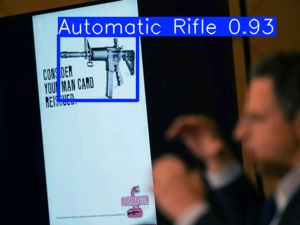

In [21]:
from IPython.display import Image as IPImage, display
from ultralytics import YOLO
import glob, os

# Auto-find best.pt
all_best = sorted(glob.glob("runs/**/best.pt", recursive=True),
                  key=os.path.getmtime, reverse=True)

# Pick any image from val set
test_images = list(val_dir.glob("*.jpg")) + list(val_dir.glob("*.png"))

if test_images and all_best:
    best_path = all_best[0]
    sample    = str(test_images[0])
    print(f"Using model  : {best_path}")
    print(f"Test image   : {sample}")

    inf_model = YOLO(best_path)
    preds = inf_model.predict(source=sample, conf=0.25, save=True,
                              project=PROJECT_NAME, name="inference_test")

    # Show the result
    saved = glob.glob(f"{PROJECT_NAME}/**/inference_test/*.jpg", recursive=True) + \
            glob.glob(f"{PROJECT_NAME}/**/inference_test/*.png", recursive=True)
    if saved:
        display(IPImage(saved[-1]))
    else:
        print("Result image not found — check the runs/ folder.")
else:
    print("ℹ️  Skipping — no val images or no best.pt found.")